In [1]:
import sqlite3
import pandas as pd

In [2]:
df = pd.read_csv(
    "../data/cleaned/datapulse_sales_cleaned.csv"
)

df["order_date"] = pd.to_datetime(df["order_date"])

df.head()

,order_id,order_date,customer_id,product,category,region,quantity,unit_price,discount,payment_method,returned,gross_sales,discount_amount,net_sales,year,month,month_name,day_name
0,O00001,2025-01-01 00:00:00.000000000,C0017,Headphones,Accessories,North,3,2500,0.00,Credit Card,No,7500,0.0,7500.0,2025,1,January,Wednesday
1,O00002,2025-01-01 02:36:59.483896779,C0056,Monitor,Electronics,East,4,15000,0.00,Credit Card,No,60000,0.0,60000.0,2025,1,January,Wednesday
2,O00003,2025-01-01 05:13:58.967793558,C0182,Laptop,Electronics,North,2,65000,0.05,Cash,No,130000,6500.0,123500.0,2025,1,January,Wednesday
3,O00004,2025-01-01 07:50:58.451690338,C0144,Laptop,Electronics,East,3,65000,0.10,Debit Card,No,195000,19500.0,175500.0,2025,1,January,Wednesday
4,O00005,2025-01-01 10:27:57.935587117,C0319,Laptop,Electronics,West,1,65000,0.00,Debit Card,No,65000,0.0,65000.0,2025,1,January,Wednesday


In [3]:
print(df.columns.tolist())

['order_id', 'order_date', 'customer_id', 'product', 'category', 'region', 'quantity', 'unit_price', 'discount', 'payment_method', 'returned', 'gross_sales', 'discount_amount', 'net_sales', 'year', 'month', 'month_name', 'day_name']


In [4]:
connection = sqlite3.connect(
    "../data/datapulse.db"
)

In [5]:
df.to_sql(
    "sales",
    connection,
    if_exists="replace",
    index=False
)

5000

In [6]:
query = """
SELECT *
FROM sales
LIMIT 10;
"""

result = pd.read_sql_query(
    query,
    connection
)

result

,order_id,order_date,customer_id,product,category,region,quantity,unit_price,discount,payment_method,returned,gross_sales,discount_amount,net_sales,year,month,month_name,day_name
0,O00001,2025-01-01 00:00:00,C0017,Headphones,Accessories,North,3,2500,0.00,Credit Card,No,7500,0.0,7500.0,2025,1,January,Wednesday
1,O00002,2025-01-01 02:36:59.483896,C0056,Monitor,Electronics,East,4,15000,0.00,Credit Card,No,60000,0.0,60000.0,2025,1,January,Wednesday
2,O00003,2025-01-01 05:13:58.967793,C0182,Laptop,Electronics,North,2,65000,0.05,Cash,No,130000,6500.0,123500.0,2025,1,January,Wednesday
3,O00004,2025-01-01 07:50:58.451690,C0144,Laptop,Electronics,East,3,65000,0.10,Debit Card,No,195000,19500.0,175500.0,2025,1,January,Wednesday
4,O00005,2025-01-01 10:27:57.935587,C0319,Laptop,Electronics,West,1,65000,0.00,Debit Card,No,65000,0.0,65000.0,2025,1,January,Wednesday
5,O00006,2025-01-01 13:04:57.419483,C0358,Keyboard,Accessories,North,2,2000,0.05,Credit Card,No,4000,200.0,3800.0,2025,1,January,Wednesday
6,O00007,2025-01-01 15:41:56.903380,C0003,Smartphone,Electronics,West,1,40000,0.00,Debit Card,No,40000,0.0,40000.0,2025,1,January,Wednesday
7,O00008,2025-01-01 18:18:56.387277,C0202,Mouse,Accessories,West,5,800,0.05,Credit Card,Yes,4000,200.0,3800.0,2025,1,January,Wednesday
8,O00009,2025-01-01 20:55:55.871174,C0101,Laptop,Electronics,South,1,65000,0.05,Credit Card,No,65000,3250.0,61750.0,2025,1,January,Wednesday
9,O00010,2025-01-01 23:32:55.355071,C0163,Monitor,Electronics,South,5,15000,0.00,Cash,No,75000,0.0,75000.0,2025,1,January,Wednesday


In [7]:
# specific columns
query = """
SELECT
    order_id,
    order_date,
    customer_id,
    product,
    net_sales
FROM sales
LIMIT 10;
"""

pd.read_sql_query(
    query,
    connection
)

,order_id,order_date,customer_id,product,net_sales
0,O00001,2025-01-01 00:00:00,C0017,Headphones,7500.0
1,O00002,2025-01-01 02:36:59.483896,C0056,Monitor,60000.0
2,O00003,2025-01-01 05:13:58.967793,C0182,Laptop,123500.0
3,O00004,2025-01-01 07:50:58.451690,C0144,Laptop,175500.0
4,O00005,2025-01-01 10:27:57.935587,C0319,Laptop,65000.0
5,O00006,2025-01-01 13:04:57.419483,C0358,Keyboard,3800.0
6,O00007,2025-01-01 15:41:56.903380,C0003,Smartphone,40000.0
7,O00008,2025-01-01 18:18:56.387277,C0202,Mouse,3800.0
8,O00009,2025-01-01 20:55:55.871174,C0101,Laptop,61750.0
9,O00010,2025-01-01 23:32:55.355071,C0163,Monitor,75000.0


In [8]:
# Ques ) Which orders generated the highest revenue?
query = """
SELECT
    order_id,
    customer_id,
    product,
    net_sales
FROM sales
ORDER BY net_sales DESC
LIMIT 10;
"""

top_orders = pd.read_sql_query(
    query,
    connection
)

top_orders

,order_id,customer_id,product,net_sales
0,O00139,C0307,Laptop,325000.0
1,O00170,C0297,Laptop,325000.0
2,O00191,C0335,Laptop,325000.0
3,O00478,C0177,Laptop,325000.0
4,O00569,C0375,Laptop,325000.0
5,O00826,C0050,Laptop,325000.0
6,O01015,C0148,Laptop,325000.0
7,O01050,C0372,Laptop,325000.0
8,O01137,C0054,Laptop,325000.0
9,O01189,C0127,Laptop,325000.0


In [9]:
# Q) What is the total net revenue?
query = """
SELECT
    SUM(net_sales) AS total_revenue
FROM sales;
"""

total_revenue_sql = pd.read_sql_query(
    query,
    connection
)

total_revenue_sql

,total_revenue
0,279094300.0


In [10]:
# Q) How many unique customers do we have?
query = """
SELECT
    COUNT(DISTINCT customer_id) AS total_customers
FROM sales;
"""

pd.read_sql_query(
    query,
    connection
)

,total_customers
0,500


In [11]:
# Q) How many unique orders are there?
query = """
SELECT
    COUNT(DISTINCT order_id) AS total_orders
FROM sales;
"""

pd.read_sql_query(
    query,
    connection
)

,total_orders
0,5000


In [12]:
# What is the average order value?
query = """
SELECT
    AVG(net_sales) AS average_order_value
FROM sales;
"""

pd.read_sql_query(
    query,
    connection
)

,average_order_value
0,55818.86


In [13]:
# Q) Which region generates the most revenue?
query = """
SELECT
    region,
    SUM(net_sales) AS revenue
FROM sales
GROUP BY region
ORDER BY revenue DESC;
"""

region_revenue = pd.read_sql_query(
    query,
    connection
)

region_revenue

,region,revenue
0,East,72130300.0
1,South,69978440.0
2,West,69370665.0
3,North,67614895.0


In [14]:
# Q) Which product generates the most revenue?
query = """
SELECT
    product,
    SUM(net_sales) AS revenue
FROM sales
GROUP BY product
ORDER BY revenue DESC;
"""

product_revenue = pd.read_sql_query(
    query,
    connection
)

product_revenue

,product,revenue
0,Laptop,115261250.0
1,Smartphone,71852000.0
2,Tablet,50097000.0
3,Monitor,26736750.0
4,Webcam,6120625.0
5,Headphones,4321375.0
6,Keyboard,3398100.0
7,Mouse,1307200.0


In [15]:
# Q) Which category generates the most revenue?
query = """
SELECT
    category,
    SUM(net_sales) AS revenue
FROM sales
GROUP BY category
ORDER BY revenue DESC;
"""

category_revenue = pd.read_sql_query(
    query,
    connection
)

category_revenue

,category,revenue
0,Electronics,263947000.0
1,Accessories,15147300.0


In [16]:
# Q) What is the average discount by product?
query = """
SELECT
    product,
    AVG(discount) AS average_discount
FROM sales
GROUP BY product
ORDER BY average_discount DESC;
"""

product_discount = pd.read_sql_query(
    query,
    connection
)

product_discount

,product,average_discount
0,Headphones,0.077725
1,Smartphone,0.077504
2,Webcam,0.075974
3,Laptop,0.075822
4,Mouse,0.075000
5,Keyboard,0.074755
6,Monitor,0.073502
7,Tablet,0.069601


In [17]:
# Q) Which products have the highest return rate?
query = """
SELECT
    product,
    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(
        DISTINCT CASE
            WHEN returned = 'Yes'
            THEN order_id
        END
    ) AS returned_orders
FROM sales
GROUP BY product;
"""

In [18]:
# Q) How much revenue does each month generate?
query = """
SELECT
    year,
    month,
    SUM(net_sales) AS revenue
FROM sales
GROUP BY
    year,
    month
ORDER BY
    year,
    month;
"""

monthly_revenue = pd.read_sql_query(
    query,
    connection
)

monthly_revenue

,year,month,revenue
0,2025,1,15486360.0
1,2025,2,15545610.0
2,2025,3,15615460.0
3,2025,4,13693690.0
4,2025,5,17074470.0
5,2025,6,14767605.0
6,2025,7,15311520.0
7,2025,8,16063435.0
8,2025,9,15232320.0
9,2025,10,16218785.0


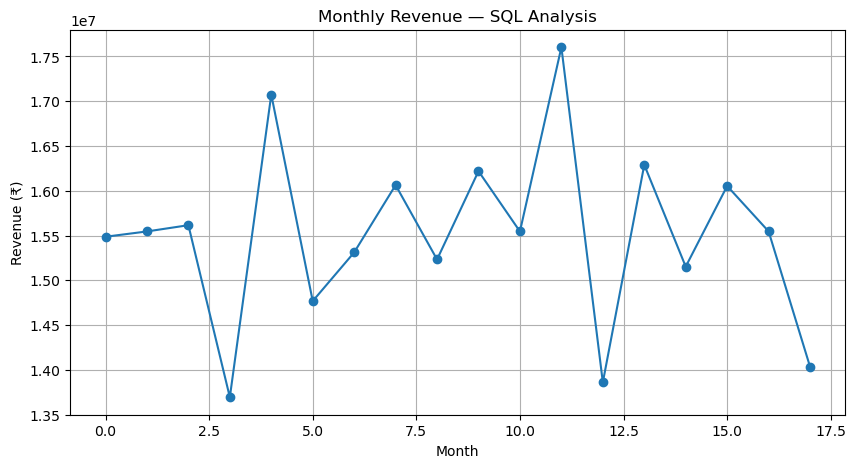

In [20]:
# visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue["revenue"],
    marker="o"
)

plt.title("Monthly Revenue — SQL Analysis")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")

plt.grid()

plt.show()

In [21]:
# KPI Query
query = """
SELECT
    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(DISTINCT customer_id) AS total_customers,
    SUM(quantity) AS total_units,
    SUM(gross_sales) AS gross_sales,
    SUM(discount_amount) AS total_discount,
    SUM(net_sales) AS net_sales,
    AVG(discount) AS average_discount
FROM sales;
"""

sql_kpis = pd.read_sql_query(
    query,
    connection
)

sql_kpis

,total_orders,total_customers,total_units,gross_sales,total_discount,net_sales,average_discount
0,5000,500,14951,301411700,22317400.0,279094300.0,0.07502


In [22]:
# calculating the same metrics in Python:
python_kpis = {
    "total_orders": df["order_id"].nunique(),
    "total_customers": df["customer_id"].nunique(),
    "total_units": df["quantity"].sum(),
    "gross_sales": df["gross_sales"].sum(),
    "total_discount": df["discount_amount"].sum(),
    "net_sales": df["net_sales"].sum(),
    "average_discount": df["discount"].mean()
}

python_kpis

{'total_orders': 5000,
 'total_customers': 500,
 'total_units': np.int64(14951),
 'gross_sales': np.int64(301411700),
 'total_discount': np.float64(22317400.0),
 'net_sales': np.float64(279094300.0),
 'average_discount': np.float64(0.07502)}

In [23]:
sql_kpis

,total_orders,total_customers,total_units,gross_sales,total_discount,net_sales,average_discount
0,5000,500,14951,301411700,22317400.0,279094300.0,0.07502


In [26]:
print("=" * 65)
print("📊 DATAPULSE — DAY 16 SQL INSIGHTS")
print("=" * 65)

print(
    f"\n1. TOTAL ORDERS:"
    f"\nDataPulse recorded "
    f"{int(sql_kpis.loc[0, 'total_orders']):,} unique orders."
)

print(
    f"\n2. TOTAL CUSTOMERS:"
    f"\nDataPulse served "
    f"{int(sql_kpis.loc[0, 'total_customers']):,} unique customers."
)

print(
    f"\n3. TOTAL UNITS:"
    f"\nA total of "
    f"{int(sql_kpis.loc[0, 'total_units']):,} units were sold."
)

print(
    f"\n4. GROSS SALES:"
    f"\nGross sales amounted to "
    f"₹{sql_kpis.loc[0, 'gross_sales']:,.2f}."
)

print(
    f"\n5. TOTAL DISCOUNTS:"
    f"\nThe dataset recorded "
    f"₹{sql_kpis.loc[0, 'total_discount']:,.2f} "
    f"in discounts."
)

print(
    f"\n6. NET SALES:"
    f"\nNet sales amounted to "
    f"₹{sql_kpis.loc[0, 'net_sales']:,.2f}."
)

top_region = region_revenue.iloc[0]

print(
    f"\n7. TOP REGION:"
    f"\n{top_region['region']} generated the highest "
    f"regional revenue of "
    f"₹{top_region['revenue']:,.2f}."
)

top_product = product_revenue.iloc[0]

print(
    f"\n8. TOP PRODUCT:"
    f"\n{top_product['product']} generated the highest "
    f"product revenue of "
    f"₹{top_product['revenue']:,.2f}."
)

top_category = category_revenue.iloc[0]

print(
    f"\n9. TOP CATEGORY:"
    f"\n{top_category['category']} generated the highest "
    f"category revenue of "
    f"₹{top_category['revenue']:,.2f}."
)


print("\n" + "=" * 65)

📊 DATAPULSE — DAY 16 SQL INSIGHTS

1. TOTAL ORDERS:
DataPulse recorded 5,000 unique orders.

2. TOTAL CUSTOMERS:
DataPulse served 500 unique customers.

3. TOTAL UNITS:
A total of 14,951 units were sold.

4. GROSS SALES:
Gross sales amounted to ₹301,411,700.00.

5. TOTAL DISCOUNTS:
The dataset recorded ₹22,317,400.00 in discounts.

6. NET SALES:
Net sales amounted to ₹279,094,300.00.

7. TOP REGION:
East generated the highest regional revenue of ₹72,130,300.00.

8. TOP PRODUCT:
Laptop generated the highest product revenue of ₹115,261,250.00.

9. TOP CATEGORY:
Electronics generated the highest category revenue of ₹263,947,000.00.

